# COURSE: A deep understanding of deep learning
## SECTION: FFNs
### LECTURE: Distributions of weights pre- and post-learning
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [26]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [27]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

print(labels.shape)
print(data.shape)

# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)

(60000,)
(60000, 784)


# Create train/test groups using DataLoader

In [28]:
# Step 1: convert to tensor
dataT   = torch.tensor( dataNorm ).float()
labelsT = torch.tensor( labels ).long()

# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)


# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

# Create the DL model

In [29]:
# create a class for the model
def createTheMNISTNet():

  class mnistNet(nn.Module):
    def __init__(self):
      super().__init__()
      
      # Create dropout object:
      self.pDropout = 0.5
      self.dropout = nn.Dropout(p=self.pDropout)

      ### input layer
      self.input = nn.Linear(784,64)
      
      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = self.dropout(x)
      x = F.relu( self.dropout(self.input(x)) )
      x = F.relu( self.dropout(self.fc1(x)) )
      x = F.relu( self.dropout(self.fc2(x)) )
      return self.output(x)
  
  # create the model instance
  net = mnistNet()
  
  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.SGD(net.parameters(),lr=.01)

  return net,lossfun,optimizer

In [30]:
### exploring the "innards" of the model

# create a temp model to explore
net = createTheMNISTNet()[0]

# summary of the entire model
print('Summary of model:')
print(net)
print(' ')

# # explore one of the layers
# print('Summary of input layer:')
# print( vars(net.input) )
# print(' ')

# # check out the matrix of weights
# print('Input layer weights:')
# print( net.input.weight.shape )
# print( net.input.weight )
# print(' ')

# # finally, extract the weights and make a histogram
# w = net.input.weight.detach().flatten()
# plt.hist(w,40)
# plt.xlabel('Weight value')
# plt.ylabel('Count')
# plt.title('Distribution of initialized input-layer weights')
# plt.show()

Summary of model:
mnistNet(
  (dropout): Dropout(p=0.5, inplace=False)
  (input): Linear(in_features=784, out_features=64, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=10, bias=True)
)
 


Text(0.5, 1.0, 'Distribution of initialized weights by layer')

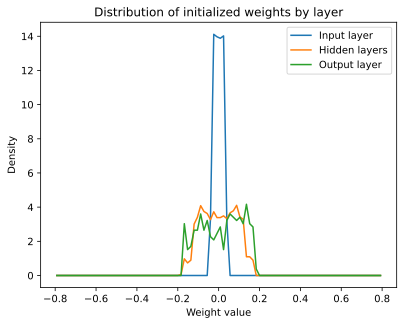

In [31]:
# a function that returns a histogram of all weights (across all layers)

def weightsHistogram(net):

  # initialize weight vector
  Win = np.array([])
  Whidden = np.array([])
  Wout = np.array([])
  
  # concatenate each set of weights
  concat_weights = lambda layer, W: np.concatenate(( W, layer[1].detach().flatten().numpy() ))
  for layer in net.named_parameters():
    if layer[0] == 'input.weight' or layer[0] == 'input.bias':
      Win = concat_weights(layer, Win)
    elif layer[0] == 'output.weight' or layer[0] == 'output.bias':
      Wout = concat_weights(layer, Wout)
    else:
      Whidden = concat_weights(layer, Whidden)
      
  # compute their histogram (note: range is hard-coded)
  def build_hist(W):
    histy,histx = np.histogram(W,bins=np.linspace(-.8,.8,101),density=True)
    histx = (histx[1:]+histx[:-1])/2
    return histx, histy
  
  histInx, histIny = build_hist(Win)
  histOutx, histOuty = build_hist(Wout)
  histHiddenx, histHiddeny = build_hist(Whidden)
  
  return histInx, histIny, histHiddenx, histHiddeny, histOutx, histOuty

# test it!
histInx, histIny, histHiddenx, histHiddeny, histOutx, histOuty = weightsHistogram(net)
plt.figure()
plt.plot(histInx, histIny)
plt.plot(histHiddenx, histHiddeny)
plt.plot(histOutx, histOuty)
plt.legend(['Input layer','Hidden layers','Output layer'])
plt.xlabel('Weight value')
plt.ylabel('Density')
plt.title('Distribution of initialized weights by layer')

# Create a function that trains the model

In [32]:
# a function that trains the model

def function2trainTheModel():

  # number of epochs
  numepochs = 100
  
  # create a new model
  net,lossfun,optimizer = createTheMNISTNet()

  # initialize losses and accuracies
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []

  # initialize histogram variables
  histInx = np.zeros((numepochs,100))
  histIny = np.zeros((numepochs,100))
  histHiddenx = np.zeros((numepochs,100))
  histHiddeny = np.zeros((numepochs,100))
  histOutx = np.zeros((numepochs,100))
  histOuty = np.zeros((numepochs,100))


  # loop over epochs
  for epochi in range(numepochs):

    # get the weights distribution at the start of this epoch
    histInx[epochi,:], histIny[epochi,:], histHiddenx[epochi,:], histHiddeny[epochi,:], histOutx[epochi,:], histOuty[epochi,:] = weightsHistogram(net)
  
    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches        = torch.argmax(yHat,axis=1) == y # booleans (false/true)
      matchesNumeric = matches.float()                # convert to numbers (0/1)
      accuracyPct    = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )                  # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      
    # compare the following really long line of code to the training accuracy lines
    testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )

  # end epochs

  # function output
  return trainAcc,testAcc,losses,net,histInx, histIny, histHiddenx, histHiddeny, histOutx, histOuty 


# Run the model and show the results!

In [33]:
trainAcc,testAcc,losses,net,histInx, histIny, histHiddenx, histHiddeny, histOutx, histOuty = function2trainTheModel()

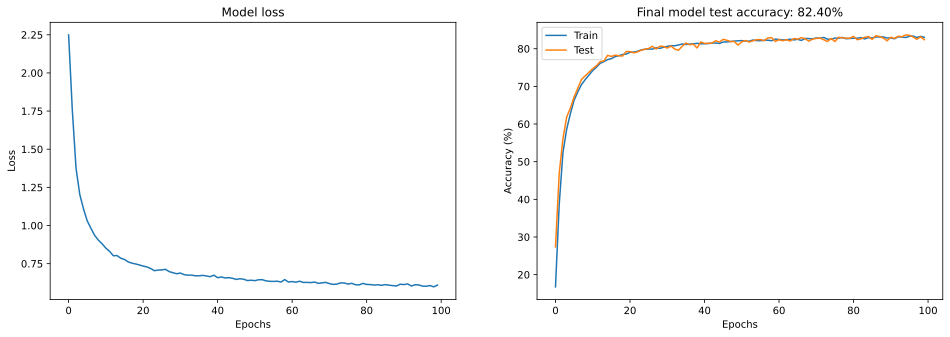

In [34]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
# ax[0].set_ylim([0,3])
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,label='Train')
ax[1].plot(testAcc,label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
# ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()

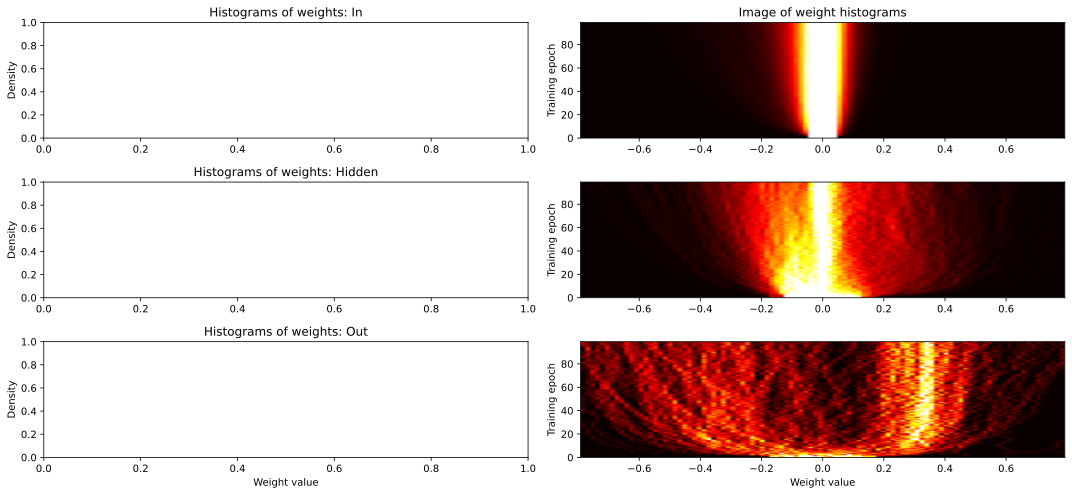

In [38]:
# show the histogram of the weights

if 'axs' in locals() or 'axs' in globals(): del axs;
if 'fig' in locals() or 'fig' in globals(): del fig;
fig,axs = plt.subplots(3,2,figsize=(15,7))
# fig.set_dpi(50)

for i in range(histIny.shape[0]):
  break
  color = [1-i/100,.3,i/100]
  axs[0,0].plot(histInx.T,histIny[i,:],color=color)
  axs[1,0].plot(histHiddenx.T,histHiddeny[i,:],color=color)
  axs[2,0].plot(histOutx.T,histOuty[i,:],color=color)

axs[0,0].set_title('Histograms of weights: In')
axs[1,0].set_title('Histograms of weights: Hidden')
axs[2,0].set_title('Histograms of weights: Out')
axs[-1,0].set_xlabel('Weight value')

for axi in range(axs.shape[0]):
  axs[axi,0].set_ylabel('Density')
  axs[axi,1].set_ylabel('Training epoch')
  
extentInx = [histInx[0][0], histInx[0][-1], 0, 99]
axs[0,1].imshow(histIny, vmin=0,vmax=3,extent=extentInx, aspect='auto',origin='lower',cmap='hot')
extentHiddenx = [histHiddenx[0][0], histHiddenx[0][-1], 0, 99]
axs[1,1].imshow(histHiddeny, vmin=0,vmax=3,extent=extentHiddenx, aspect='auto',origin='lower',cmap='hot')
extentOutx = [histOutx[0][0], histOutx[0][-1], 0, 99]
axs[2,1].imshow(histOuty, vmin=0,vmax=3,extent=extentOutx, aspect='auto',origin='lower',cmap='hot')
  
axs[-1,1].set_xlabel('Weight value')
axs[0,1].set_title('Image of weight histograms')

fig.tight_layout()
plt.show()

# Additional explorations

In [ ]:
# 1) Separate the distributions for input, hidden, and output layers. 
#    Are the learning-related changes similar across all layers?
# Answer: All layer's weights distributions are getting wider in weight values - meaning the values are getting bigger. Althoguh the density from input to output is decreasing, s.t.
# output layers density stays prety noise and less changed compared with it's starting values. Also compared with input and hidden layers the weigts value s change of the output
# layer is less significant.
# 
# 2) Re-run the code without data normalization. 
#    Does the scale of the data affect the scale of the weights?
# Answer: No, there is no noticeable effect of weights values scale, but the weights values resolution seems to be more dense.
# 
# 3) Test how dropout regularization affects the weight distributions.
# Answer: Dropout redistribution follows similiar pattern as without dropout. But the hidden and output weights distributions arte getting more wider in range of values.
# Also boths distributions becomming clearly visible distribution peaks. The output weights distribution becomes it's maximum shifted right from zero, while hidden wights maximum stays around 0.